# Regresión Logística
## Predicción de Nivel de Riesgo de Meningitis

**Dataset:** Meningitis Dataset  
**Fuente:** Local CSV

## Variable objetivo (Y)
`risk_encoded` — Nivel de riesgo (1=High Risk, 0=Moderate/Low Risk)

## Features seleccionadas (n=8)

| # | Feature | Descripción | Justificación |
|---|---|---|---|
| 1 | `Age` | Edad del paciente | Factor demográfico importante |
| 2 | `WBC_Count` | Conteo de glóbulos blancos en LCR | Indicador de infección |
| 3 | `Protein_Level` | Nivel de proteína en LCR | Alta proteína indica gravedad |
| 4 | `Glucose_Level` | Nivel de glucosa en LCR | Baja glucosa indica bacteriana |
| 5 | `Hemoglobin` | Nivel de hemoglobina | Estado general del paciente |
| 6 | `WBC_Blood_Count` | Conteo de glóbulos blancos en sangre | Respuesta inmune sistémica |
| 7 | `Platelets` | Conteo de plaquetas | Indicador de coagulación |
| 8 | `CRP_Level` | Proteína C reactiva | Marcador de inflamación |

## Columnas descartadas

| Columna | Razón |
|---|---|
| `Patient_ID` | Identificador — sin relación con diagnóstico |
| `Gender` | Categórica — requiere encoding |
| `Pathogen_Present` | Categórica |
| `Diagnosis` | Categórica |
| `Outcome` | Filtrado de información |

## Modelo a implementar
**Regresión Logística Simple** para clasificación binaria

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

## 1. Función Sigmoid

In [3]:
def sigmoid(z):
    z = np.array(z)
    z = np.clip(z, -500, 500)
    g = 1 / (1 + np.exp(-z))
    return g

## 2. Carga del Dataset

Se carga el dataset de meningitis desde CSV.
Se seleccionan features numéricas clínicas.
Se rellenan nulos con la mediana.

In [4]:
data = pd.read_csv('mening missing 12.csv')
data['risk_encoded'] = (data['Risk_Level'] == 'High Risk').astype(int)

FEATURES = [
    'Age',
    'WBC_Count',
    'Protein_Level',
    'Glucose_Level',
    'Hemoglobin',
    'WBC_Blood_Count',
    'Platelets',
    'CRP_Level',
]
TARGET = 'risk_encoded'

for col in FEATURES:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

X = data[FEATURES].values.astype(np.float64)
y = data[TARGET].values.astype(np.float64)

m = y.size
print(f'Dimensiones dataset : {data.shape}')
print(f'X shape             : {X.shape}')
print(f'y shape             : {y.shape}')
print(f'm                   : {m:,}')
print(f'n features          : {len(FEATURES)}')

Dimensiones dataset : (1200, 15)
X shape             : (1200, 8)
y shape             : (1200,)
m                   : 1,200
n features          : 8


## 3. Exploración del Dataset

In [5]:
print('=== Información general ===')
print(data.info())
print()
print('=== Estadísticas básicas ===')
print(data[FEATURES + [TARGET]].describe())

=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        1200 non-null   int64  
 1   Age               1200 non-null   float64
 2   Gender            1191 non-null   str    
 3   WBC_Count         1200 non-null   float64
 4   Protein_Level     1200 non-null   float64
 5   Glucose_Level     1200 non-null   float64
 6   Pathogen_Present  1192 non-null   str    
 7   Diagnosis         1188 non-null   str    
 8   Outcome           1190 non-null   str    
 9   Hemoglobin        1200 non-null   float64
 10  WBC_Blood_Count   1200 non-null   float64
 11  Platelets         1200 non-null   float64
 12  CRP_Level         1200 non-null   float64
 13  Risk_Level        1200 non-null   str    
 14  risk_encoded      1200 non-null   int64  
dtypes: float64(8), int64(2), str(5)
memory usage: 140.8 KB
None

=== Estadís

## 4. Visualización (primeras 2 features)

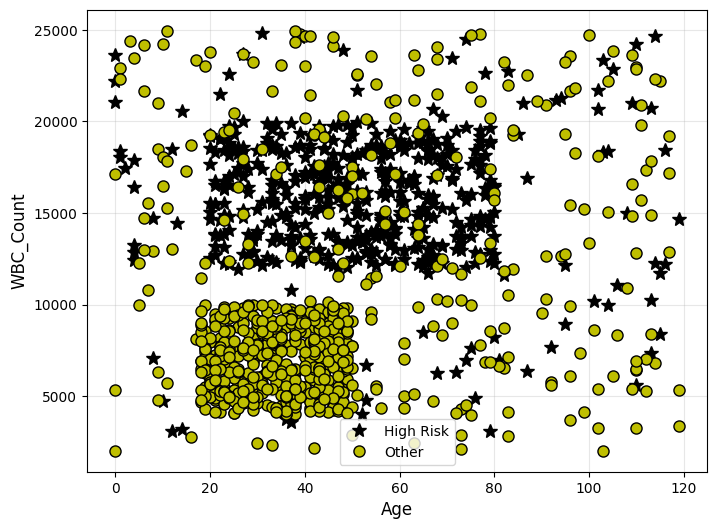

In [6]:
def plotData(X, y):
    fig = plt.figure(figsize=(8, 6))
    pos = y == 1
    neg = y == 0

    plt.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10, label='High Risk')
    plt.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1, label='Other')
    plt.xlabel(FEATURES[0], fontsize=12)
    plt.ylabel(FEATURES[1], fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plotData(X, y)

## 5. Agregar término de intercepción

In [7]:
m, n = X.shape
X = np.concatenate([np.ones((m, 1)), X], axis=1)

print(f'X shape con intercepción: {X.shape}')
print(f'Primera fila: {X[0]}')

X shape con intercepción: (1200, 9)
Primera fila: [1.00000e+00 1.01000e+02 8.62400e+03 1.60000e+01 8.30000e+01 1.50000e+01
 7.26900e+03 1.60949e+05 7.10000e+01]


## 6. Función de Costo y Gradiente

### Función de Costo
$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log(h_\theta(x^{(i)})) - (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]$$

### Gradiente
$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

In [8]:
def costFunction(theta, X, y):
    m = y.size
    
    h = sigmoid(X.dot(theta.T))
    
    J = (1 / m) * np.sum(-y * np.log(h + 1e-10) - (1 - y) * np.log(1 - h + 1e-10))
    grad = (1 / m) * (h - y).dot(X)
    
    return J, grad

## 7. Prueba de la función de costo

In [9]:
initial_theta = np.zeros(n + 1)
cost, grad = costFunction(initial_theta, X, y)

print('Costo en theta inicial (zeros): {:.4f}'.format(cost))
print('Gradiente en theta inicial:')
print(grad)

Costo en theta inicial (zeros): 0.6931
Gradiente en theta inicial:
[ 7.91666667e-02  1.71833333e+00 -5.17107500e+02 -8.99416667e+00
  1.30562500e+01  2.60000000e+00 -6.75525417e+02  4.10776667e+04
 -2.08750000e+00]


## 8. Optimización con scipy.optimize

In [10]:
options = {'maxiter': 1000}

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

cost = res.fun
theta = res.x

print('Costo con theta optimizado: {:.4f}'.format(cost))
print('Theta optimizado:')
print(theta)

Costo con theta optimizado: 0.3146
Theta optimizado:
[-1.23092704e-03  5.59567709e-03  9.90289792e-05  6.83827785e-03
 -2.97148151e-02 -1.38139133e-01  4.84541231e-05 -2.73548182e-06
  2.34420747e-03]


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_13080\430441082.py:3: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,


## 9. Función de Predicción

In [11]:
def predict(theta, X):
    m = X.shape[0]
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

## 10. Evaluación del Modelo

In [12]:
# Predicciones
p = predict(theta, X)
accuracy = np.mean(p == y) * 100

print('Precisión de entrenamiento: {:.2f}%'.format(accuracy))

# Matriz de confusión
tp = np.sum((p == 1) & (y == 1))
tn = np.sum((p == 0) & (y == 0))
fp = np.sum((p == 1) & (y == 0))
fn = np.sum((p == 0) & (y == 1))

print(f'\nMatriz de Confusión:')
print(f'TP: {tp}, FN: {fn}')
print(f'FP: {fp}, TN: {tn}')
print(f'\nSensitibilidad (TPR): {tp / (tp + fn):.4f}')
print(f'Especificidad (TNR): {tn / (tn + fp):.4f}')
print(f'Precisión (PPV): {tp / (tp + fp):.4f}')

Precisión de entrenamiento: 87.83%

Matriz de Confusión:
TP: 438, FN: 67
FP: 79, TN: 616

Sensitibilidad (TPR): 0.8673
Especificidad (TNR): 0.8863
Precisión (PPV): 0.8472


## 11. Probabilidades de Predicción

In [13]:
# Predicciones probabilísticas
h = sigmoid(X.dot(theta.T))

# Mostrar algunos ejemplos
print('Ejemplos de predicciones probabilísticas:')
print()
for i in range(10):
    prob = h[i]
    pred = 1 if prob >= 0.5 else 0
    real = int(y[i])
    match = '✓' if pred == real else '✗'
    print(f'Muestra {i}: Prob={prob:.4f}, Pred={pred}, Real={real} {match}')

Ejemplos de predicciones probabilísticas:

Muestra 0: Prob=0.0506, Pred=0, Real=0 ✓
Muestra 1: Prob=0.4339, Pred=0, Real=1 ✗
Muestra 2: Prob=0.3114, Pred=0, Real=0 ✓
Muestra 3: Prob=0.7010, Pred=1, Real=0 ✗
Muestra 4: Prob=0.8718, Pred=1, Real=1 ✓
Muestra 5: Prob=0.8877, Pred=1, Real=1 ✓
Muestra 6: Prob=0.8831, Pred=1, Real=1 ✓
Muestra 7: Prob=0.9092, Pred=1, Real=1 ✓
Muestra 8: Prob=0.0418, Pred=0, Real=0 ✓
Muestra 9: Prob=0.0621, Pred=0, Real=0 ✓


## 12. Histogramas de Probabilidades

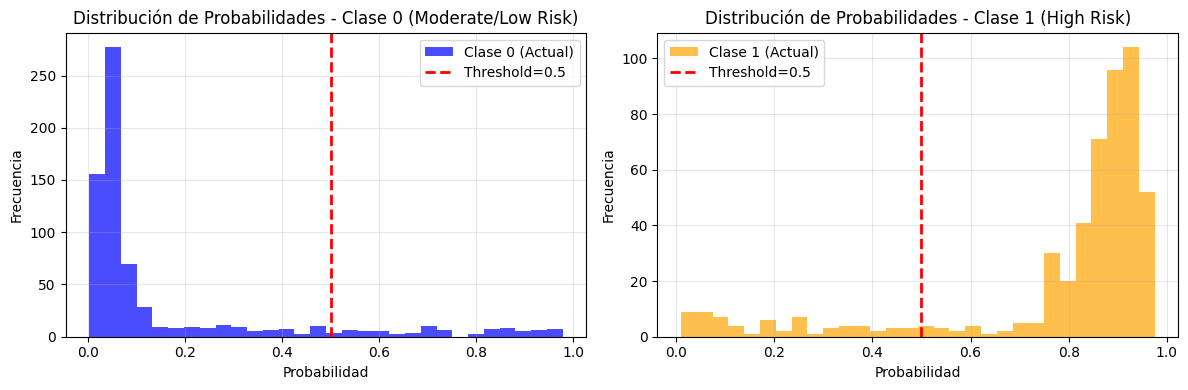

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de probabilidades para clase 0
axes[0].hist(h[y == 0], bins=30, alpha=0.7, color='blue', label='Clase 0 (Actual)')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[0].set_xlabel('Probabilidad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Probabilidades - Clase 0 (Moderate/Low Risk)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma de probabilidades para clase 1
axes[1].hist(h[y == 1], bins=30, alpha=0.7, color='orange', label='Clase 1 (Actual)')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[1].set_xlabel('Probabilidad')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Probabilidades - Clase 1 (High Risk)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Ejemplo de Predicción en Nuevo Dato

In [15]:
# Usar valores normalizados aproximadamente en la mediana
sample = np.array([1, 45, 120, 60, 40, 8, 200, 120, 15])

prob = sigmoid(np.dot(sample, theta))
pred = 1 if prob >= 0.5 else 0

print(f'Predicción para nuevo paciente:')
print(f'Probabilidad de High Risk: {prob:.4f}')
print(f'Predicción: {"High Risk" if pred == 1 else "Moderate/Low Risk"}')

Predicción para nuevo paciente:
Probabilidad de High Risk: 0.1713
Predicción: Moderate/Low Risk
